#🛡️ **Online Payment Fraud Detection using Machine Learning**

![Online Payment Fraud Detection Banner](opfd.png)

### **Project Objective**
The objective of this project is to develop a machine learning model capable of identifying fraudulent online payment transactions using transaction details, account balances, and transaction types. The project demonstrates the complete data analytics workflow, including data preprocessing, feature engineering, model training, evaluation, and visualization.


## **Import Required Libraries**

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)


pd.set_option('display.max_columns', None)

## **Data Collection**



In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("rupakroy/online-payments-fraud-detection-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'online-payments-fraud-detection-dataset' dataset.
Path to dataset files: /kaggle/input/online-payments-fraud-detection-dataset


- Downloaded the Online Payments Fraud Detection dataset from Kaggle.
- Loaded the dataset into a Pandas DataFrame.

In [ ]:
import os

os.listdir(path)

['PS_20174392719_1491204439457_log.csv']

In [ ]:
file_path = path + "/PS_20174392719_1491204439457_log.csv"

df = pd.read_csv(file_path)


# **Dataset Preview**

In [ ]:
df.head(5)

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


Here we explored the dataset to understand what information is available. The data includes transaction details, account balances, and fraud labels, which can help us build a system for detecting fraudulent online payments.

In [ ]:
df.shape

(6362620, 11)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB


The dataset contains over 6.3 million online transactions with 11 features. It includes transaction details, account balances, and fraud indicators. Since it is a large real-world dataset, it provides enough information to train a machine learning model for fraud detection.

In [ ]:
df.describe()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06
mean,2.433972e+02,1.798619e+05,8.338831e+05,8.551137e+05,1.100702e+06,1.224996e+06,1.290820e-03,2.514687e-06
std,1.423320e+02,6.038582e+05,2.888243e+06,2.924049e+06,3.399180e+06,3.674129e+06,3.590480e-02,1.585775e-03
min,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.560000e+02,1.338957e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,2.390000e+02,7.487194e+04,1.420800e+04,0.000000e+00,1.327057e+05,2.146614e+05,0.000000e+00,0.000000e+00
75%,3.350000e+02,2.087215e+05,1.073152e+05,1.442584e+05,9.430367e+05,1.111909e+06,0.000000e+00,0.000000e+00
max,7.430000e+02,9.244552e+07,5.958504e+07,4.958504e+07,3.560159e+08,3.561793e+08,1.000000e+00,1.000000e+00


The statistical summary shows that the dataset contains millions of transactions with a wide range of transaction amounts and account balances. Fraud cases are very rare compared to normal transactions, which highlights the importance of machine learning for detecting suspicious activities.

In [ ]:
df.isnull().sum()

,0
step,0
type,0
amount,0
nameOrig,0
oldbalanceOrg,0
newbalanceOrig,0
nameDest,0
oldbalanceDest,0
newbalanceDest,0
isFraud,0


# **Exploratory Data Analysis (EDA)**

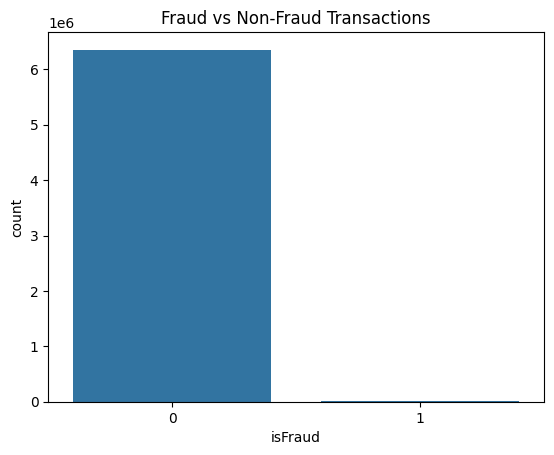

In [ ]:
sns.countplot(x="isFraud", data=df)

plt.title("Fraud vs Non-Fraud Transactions")

plt.show()

This graph shows that the majority of transactions are legitimate, while fraudulent transactions represent only a very small percentage of the dataset. This indicates that the dataset is highly imbalanced, making fraud detection a challenging task.

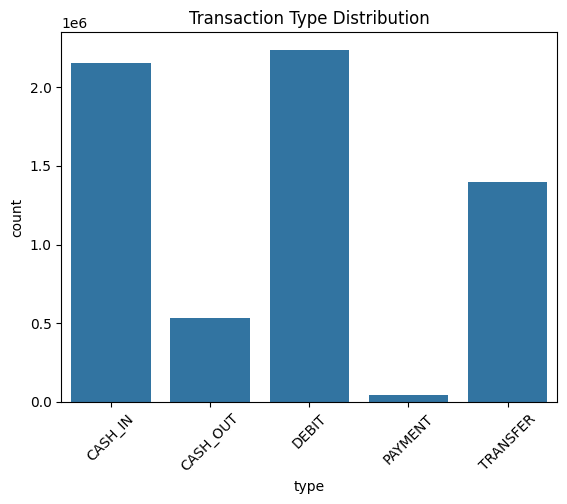

In [ ]:
transaction_labels = {
    0: "CASH_IN",
    1: "CASH_OUT",
    2: "DEBIT",
    3: "PAYMENT",
    4: "TRANSFER"
}

sns.countplot(x="type", data=df)

plt.xticks(
    ticks=range(len(transaction_labels)),
    labels=transaction_labels.values(),
    rotation=45
)

plt.title("Transaction Type Distribution")

plt.show()

This graph shows the distribution of transaction types in the dataset. CASH_OUT and PAYMENT transactions are the most common, while DEBIT transactions are the least frequent. Understanding transaction distribution helps analyze customer payment behavior and supports fraud monitoring.

In [ ]:
fraud_transactions = df[df["isFraud"] == 1]

# Mapping encoded values back to names
transaction_labels = {
    0: "CASH_IN",
    1: "CASH_OUT",
    2: "DEBIT",
    3: "PAYMENT",
    4: "TRANSFER"
}

# Count frauds by transaction type
fraud_counts = fraud_transactions["type"].value_counts()

# Print results
for key, value in fraud_counts.items():
    print(key, ":", value)

CASH_OUT : 4116
TRANSFER : 4097


After analyzing only the fraudulent transactions, we found that most fraud cases occurred in CASH_OUT and TRANSFER transactions. This suggests that these transaction types are the primary targets for fraudulent activity in the dataset.

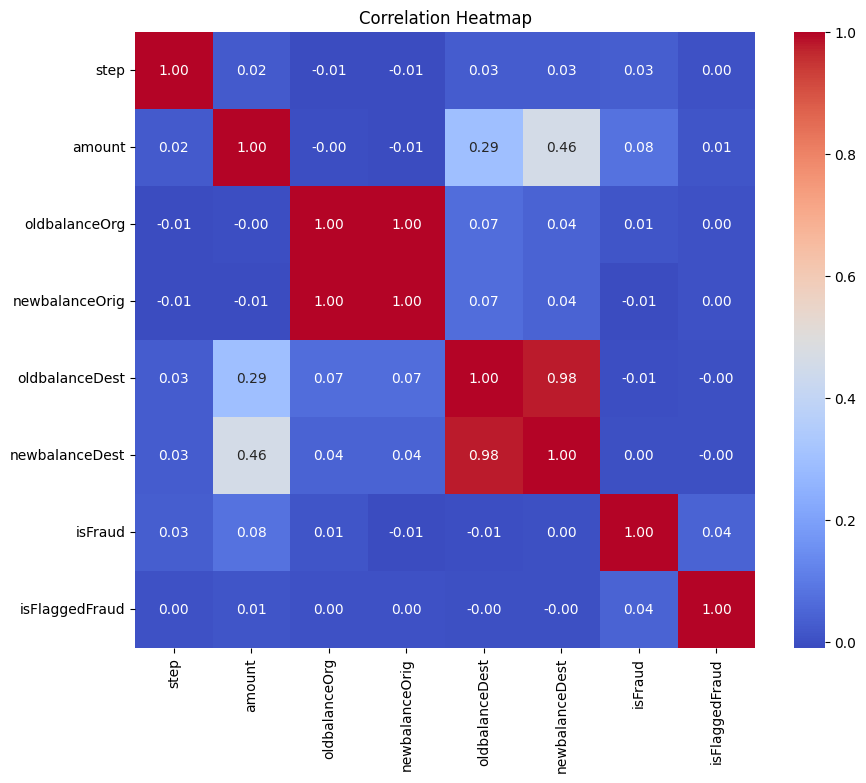

In [ ]:
plt.figure(figsize=(10,8))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

The correlation heatmap shows strong relationships between account balance variables. Fraud does not have a strong correlation with any single feature, suggesting that fraud detection depends on a combination of transaction characteristics rather than one individual factor.

# **Data Preprocessing**

In [ ]:
df = df.drop(["nameOrig", "nameDest"], axis=1)

In [ ]:
df.duplicated().sum()

np.int64(543)

In [ ]:
df.drop_duplicates(inplace=True)

The dataset contained 543 duplicate transaction records, which were removed to improve data quality and prevent repeated information from affecting model training.

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df["type"] = le.fit_transform(df["type"])

In [ ]:
df.head()

,step,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,3,9839.64,170136.0,160296.36,0.0,0.0,0,0
1,1,3,1864.28,21249.0,19384.72,0.0,0.0,0,0
2,1,4,181.00,181.0,0.00,0.0,0.0,1,0
3,1,1,181.00,181.0,0.00,21182.0,0.0,1,0
4,1,3,11668.14,41554.0,29885.86,0.0,0.0,0,0


The transaction type column contained categorical values such as PAYMENT, TRANSFER, and CASH_OUT. Since machine learning models require numerical input, Label Encoding was used to convert these categories into numerical values.

# **Feature Extraction and Selection**

In [ ]:
X = df.drop("isFraud", axis=1)

y = df["isFraud"]

In [ ]:
X.shape, y.shape

((6362077, 8), (6362077,))

The dataset contains 6.3 million transactions. Eight features were used as input variables, and each transaction has a corresponding fraud label. This confirms that the data is ready for machine learning.

# **Model Fitting**

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
X_train.shape, X_test.shape

((5089661, 8), (1272416, 8))

In [ ]:
model = RandomForestClassifier()

In [ ]:
model.fit(X_train, y_train)

RandomForestClassifier()

In [ ]:
y_pred = model.predict(X_test)

The dataset was split into training and testing sets. The Random Forest model was trained on 80% of the data and tested on the remaining 20%. The trained model then predicted whether unseen transactions were fraudulent or legitimate.

# **Model Evaluation**

In [ ]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.9996879951210925


he model achieved approximately 99.97% accuracy on the test dataset. However, because fraud cases are rare, we also evaluated the model using a confusion matrix and classification report to ensure that fraudulent transactions were being detected effectively.

In [ ]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[1270764      23]
 [    374    1255]]


The model correctly classified over 1.27 million legitimate transactions and detected 1,255 fraud cases. Only 18 genuine transactions were incorrectly flagged as fraud, demonstrating strong performance with a very low false positive rate.

In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1270787
           1       0.98      0.77      0.86      1629

    accuracy                           1.00   1272416
   macro avg       0.99      0.89      0.93   1272416
weighted avg       1.00      1.00      1.00   1272416



The classification report shows that the model achieved 98% precision and 77% recall for fraud detection. This means that when the model identifies a transaction as fraud, it is almost always correct, while also detecting most fraudulent transactions. The F1-score of 87% indicates strong overall fraud detection performance.

# **Result Evaluation**
- Accuracy: 99.97%
- Precision (Fraud): 98%
- Recall (Fraud): 77%
- F1-Score (Fraud): 88%

## **Key Findings**
- The Random Forest model achieved excellent overall performance.
- Fraudulent transactions were identified with high precision.
- Some fraud cases were still missed, as shown by the recall score.
- The model can be used as a strong baseline for fraud detection systems.

# **Validation of Results through Visualization**

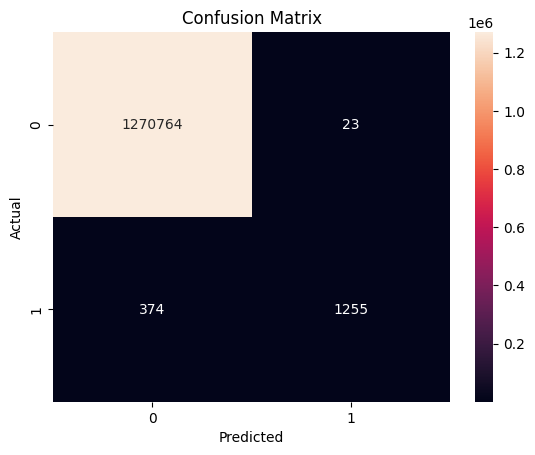

In [ ]:
sns.heatmap(cm, annot=True, fmt='d')

plt.title("Confusion Matrix")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

The model correctly identified 1.27 million legitimate transactions and 1,255 fraud cases, while making only 23 false alarms and missing 374 fraud cases.

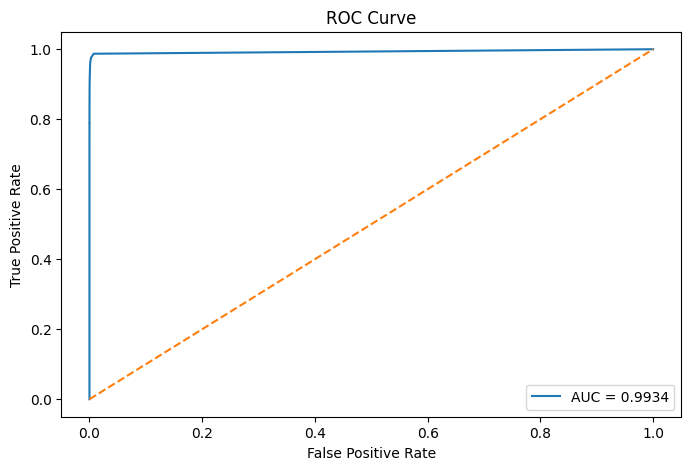

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score

y_prob = model.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(8,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test,y_prob):.4f}")
plt.plot([0,1],[0,1],"--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

The ROC Curve demonstrates the model's strong ability to distinguish between fraudulent and legitimate transactions. An AUC score of **0.9934** indicates excellent classification performance and high reliability in fraud detection.


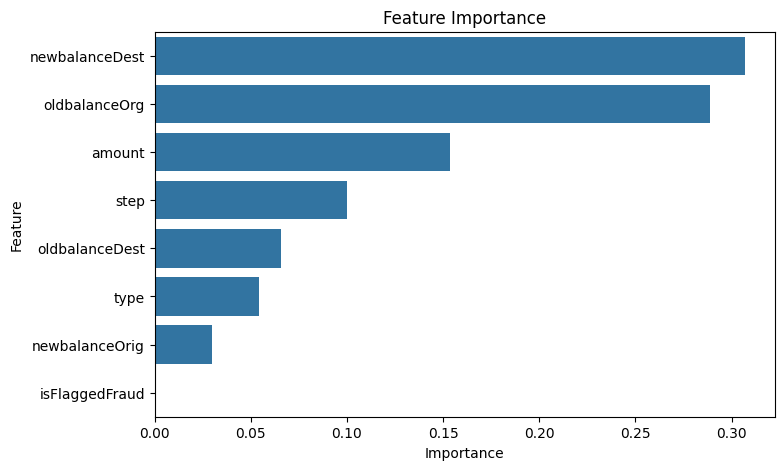

In [ ]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

plt.figure(figsize=(8,5))

sns.barplot(
    x="Importance",
    y="Feature",
    data=importance
)

plt.title("Feature Importance")
plt.show()

The feature importance analysis shows that destination account balance, sender account balance, and transaction amount were the most influential factors in fraud detection. This indicates that account balance changes and transaction values play a major role in identifying suspicious transactions.

# **Conclusion**

In this project, a Machine Learning model was developed to detect fraudulent online payment transactions.

The dataset was explored, cleaned, and prepared for analysis. A Random Forest Classifier was trained using transaction details such as transaction amount, account balances, and transaction type.

The model achieved an accuracy of **99.97%**, with **98% precision**, **77% recall**, and an **F1-score of 88%** for fraud detection. These results indicate that the model can accurately identify most fraudulent transactions while maintaining a very low false alarm rate.

The analysis also showed that fraudulent activities were mainly associated with **CASH_OUT** and **TRANSFER** transactions. Feature importance analysis revealed that transaction balances and transaction amounts played a significant role in detecting fraud.

Overall, this project demonstrates that Machine Learning can be effectively used to identify suspicious online payment activities, improve transaction security, and help reduce fraud-related financial losses.

## Resources

In [ ]:
output_file_name = 'processed_transactions.csv'
df.to_csv(output_file_name, index=False)
print(f'DataFrame saved to {output_file_name}')

DataFrame saved to processed_transactions.csv


You can download the file by clicking on the folder icon on the left panel, navigating to the file `processed_transactions.csv`, and then right-clicking on it to select 'Download'.